# Предсказание данных об оттоке клиентов

__Описание проекта:__  оператор связи «ТелеДом» хочет научиться прогнозировать отток клиентов. Если выяснится, что пользователь планирует уйти, сотрудники начнут предлагать ему промокоды и специальные условия. Команда оператора собрала персональные данные о некоторых клиентах, информацию об их тарифах и договорах.

__Цель исследования:__ используя данные о пользователях обучить модель, прогнозирующую отток клиентов

__Описание заказчика:__

Оператор предоставляет два основных типа услуг:
1. Стационарную телефонную связь. Телефон можно подключить к нескольким линиям одновременно.
2. Интернет. Подключение бывает двух типов: через телефонную линию DSL (англ. digital subscriber line — «цифровая абонентская линия») или оптоволоконный кабель (англ. fiber optic).

Также абонентам доступен ряд услуг:
- Интернет-безопасность: антивирус (Device Protection) и блокировка опасных сайтов (Online Security);
- Выделенная линия технической поддержки (Tech Support);
- Облачное хранилище файлов для резервного копирования данных (Online Backup);
- Стриминговое телевидение (Streaming TV) и каталог фильмов (Streaming Movies).

__Ход исследования:__
<br><br>
- Подготовка данных: подключение к БД, загрузка датафреймов, получение общей информации;
- Предобработка данных: обработка пропусков, дубликатов, поиск аномалий;
- Исследовательский анализ: построение распределений и зависимостей в данных;
- Исследование корелляции между входными признаками;
- Объединение данных;
- Кодирование и нормализация данных;
- Проведение отбора моделей на кросс-валидации с подбором гиперпараметров;
- Выбор лучшей модели и предсказание на тестовой выборке;
- Анализ работы модели.

## Подготовка данных

### Загрузка библиотек

In [1]:
!pip install -Uq seaborn phik skimpy pandas numpy==2.3 optuna lightgbm catboost xgboost shap

In [2]:
import math
import random
import optuna
import os
import shap
import lightgbm as lgb

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import phik

from itertools import cycle, islice

from matplotlib.lines import Line2D

from seaborn import heatmap

from skimpy import skim

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import roc_auc_score, f1_score, fbeta_score, precision_score, recall_score, precision_recall_curve, \
confusion_matrix, roc_curve, PrecisionRecallDisplay, RocCurveDisplay, accuracy_score

from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sqlalchemy import create_engine

from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

In [3]:
sns.set_style('darkgrid')

In [4]:
def short_summary(dataframe):
	print('\033[1mКраткая информация:\033[0m\n')
	dataframe.info()
	print('\n\n\033[1mРазмерность:\033[0m', dataframe.shape, end='\n\n\n')
	print('\033[1m5 случайных строк датафрейма:\033[0m\n')

In [5]:
def data_load(name):
	
	try:
		data = pd.read_sql_query(
			f'SELECT * FROM {name}',
			con=engine
			)
		
	except:
		print('Таблица не обнаружена')
		return
		
	short_summary(data)
    
	display(data.head(5))

	skim(data)

	return data

In [6]:
RANDOM_STATE = 2082026

### Загрузка данных

In [7]:
db_name = 'ds-plus-final.db'
engine = create_engine(f'sqlite:///{db_name}', echo=False) 

Рассмотрим файлы базы данных:

In [8]:
q = 'SELECT name FROM sqlite_master WHERE type="table"'

In [9]:
pd.read_sql_query(
	q,
	con=engine
).T

,0,1,2,3,4,5,6,7,8,9,10
name,data_arc,data_bulk,data_bulk_time,data_wire_time,contract,personal,phone,internet,data_gas,data_temp,data_wire


Нас интересуют согласно данным заказчика только:
- contract;
- personal;
- internet;
- phone.

In [10]:
start_contract_df = data_load('contract')

Краткая информация:

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        7043 non-null   str  
 1   BeginDate         7043 non-null   str  
 2   EndDate           7043 non-null   str  
 3   Type              7043 non-null   str  
 4   PaperlessBilling  7043 non-null   str  
 5   PaymentMethod     7043 non-null   str  
 6   MonthlyCharges    7043 non-null   str  
 7   TotalCharges      7043 non-null   str  
dtypes: str(8)
memory usage: 897.1 KB


Размерность: (7043, 8)


5 случайных строк датафрейма:



,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 7043   │ │ string      │ 8     │                                                          │
│ │ Number of columns │ 8      │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃           ┃           ┃           ┃           ┃ chars per ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest  ┃ longest   ┃ min       ┃ max       ┃ row       ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ customerI │  0 │    0 │ 7590-VHVE │ 7590-VHVE │ 0002-ORFB │ 9995-HOTO │        10 │         1 │       7043 │  │
│ │     D     │    │      │     G     │     G     │     O     │     H     │           │           │            │  │
│ │ BeginDate │  0 │    0 │ 2020-01-0 │ 2020-01-0 │ 2013-10-0 │ 2020-02-0 │        10 │         1 │       7043 │  │
│ │           │    │      │     1     │     1     │     1     │     1     │           │           │            │  │
│ │  EndDate  │  0 │    0 │    No     │ 2017-05-0 │ 2014-06-0 │    No     │      3.25 │         1 │       7043 │  │
│ │           │    │      │           │     1     │     1     │           │           │           │            │  │
│ │   Type    │  0 │    0 │ One year  │ Month-to- │ Month-to- │ Two year  │      11.3 │       1.4 │      10211 │  │
│ │           │    │      │           │   month   │   month   │           │           │           │            │  │
│ │ Paperless │  0 │    0 │    No     │    Yes    │    No     │    Yes    │      2.59 │         1 │       7043 │  │
│ │  Billing  │    │      │           │           │           │           │           │           │            │  │
│ │ PaymentMe │  0 │    0 │  Mailed   │   Bank    │   Bank    │  Mailed   │      18.6 │       2.4 │      17152 │  │
│ │   thod    │    │      │   check   │ transfer  │ transfer  │   check   │           │           │            │  │
│ │           │    │      │           │ (automati │ (automati │           │           │           │            │  │
│ │           │    │      │           │    c)     │    c)     │           │           │           │            │  │
│ │ MonthlyCh │  0 │    0 │   42.3    │  100.35   │   100.0   │   99.95   │      4.63 │         1 │       7043 │  │
│ │   arges   │    │      │           │           │           │           │           │           │            │  │
│ │ TotalChar │  0 │    0 │           │  2071.84  │           │   999.9   │      6.07 │         1 │       7054 │  │
│ │    ges    │    │      │           │           │           │           │           │           │            │  │
│ └───────────┴────┴──────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [11]:
start_personal_df = data_load('personal')

Краткая информация:

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     7043 non-null   str  
 1   gender         7043 non-null   str  
 2   SeniorCitizen  7043 non-null   str  
 3   Partner        7043 non-null   str  
 4   Dependents     7043 non-null   str  
dtypes: str(5)
memory usage: 418.1 KB


Размерность: (7043, 5)


5 случайных строк датафрейма:



,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 7043   │ │ string      │ 5     │                                                          │
│ │ Number of columns │ 5      │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃           ┃           ┃           ┃           ┃ chars per ┃ words per  ┃ total     ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest  ┃ longest   ┃ min       ┃ max       ┃ row       ┃ row        ┃ words     ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━┩  │
│ │ customerI │  0 │    0 │ 7590-VHVE │ 7590-VHVE │ 0002-ORFB │ 9995-HOTO │        10 │          1 │      7043 │  │
│ │     D     │    │      │     G     │     G     │     O     │     H     │           │            │           │  │
│ │  gender   │  0 │    0 │   Male    │  Female   │  Female   │   Male    │      4.99 │          1 │      7043 │  │
│ │ SeniorCit │  0 │    0 │     0     │     0     │     0     │     1     │         1 │          1 │      7043 │  │
│ │   izen    │    │      │           │           │           │           │           │            │           │  │
│ │  Partner  │  0 │    0 │    No     │    Yes    │    No     │    Yes    │      2.48 │          1 │      7043 │  │
│ │ Dependent │  0 │    0 │    No     │    Yes    │    No     │    Yes    │       2.3 │          1 │      7043 │  │
│ │     s     │    │      │           │           │           │           │           │            │           │  │
│ └───────────┴────┴──────┴───────────┴───────────┴───────────┴───────────┴───────────┴────────────┴───────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [12]:
start_internet_df = data_load('internet')

Краткая информация:

<class 'pandas.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        5517 non-null   str  
 1   InternetService   5517 non-null   str  
 2   OnlineSecurity    5517 non-null   str  
 3   OnlineBackup      5517 non-null   str  
 4   DeviceProtection  5517 non-null   str  
 5   TechSupport       5517 non-null   str  
 6   StreamingTV       5517 non-null   str  
 7   StreamingMovies   5517 non-null   str  
dtypes: str(8)
memory usage: 517.8 KB


Размерность: (5517, 8)


5 случайных строк датафрейма:



,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 5517   │ │ string      │ 8     │                                                          │
│ │ Number of columns │ 8      │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃           ┃           ┃           ┃           ┃ chars per ┃ words per  ┃ total     ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest  ┃ longest   ┃ min       ┃ max       ┃ row       ┃ row        ┃ words     ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━┩  │
│ │ customerI │  0 │    0 │ 7590-VHVE │ 7590-VHVE │ 0002-ORFB │ 9995-HOTO │        10 │          1 │      5517 │  │
│ │     D     │    │      │     G     │     G     │     O     │     H     │           │            │           │  │
│ │ InternetS │  0 │    0 │    DSL    │   Fiber   │    DSL    │   Fiber   │      7.49 │        1.6 │      8613 │  │
│ │  ervice   │    │      │           │   optic   │           │   optic   │           │            │           │  │
│ │ OnlineSec │  0 │    0 │    No     │    Yes    │    No     │    Yes    │      2.37 │          1 │      5517 │  │
│ │   urity   │    │      │           │           │           │           │           │            │           │  │
│ │ OnlineBac │  0 │    0 │    No     │    Yes    │    No     │    Yes    │      2.44 │          1 │      5517 │  │
│ │    kup    │    │      │           │           │           │           │           │            │           │  │
│ │ DevicePro │  0 │    0 │    No     │    Yes    │    No     │    Yes    │      2.44 │          1 │      5517 │  │
│ │  tection  │    │      │           │           │           │           │           │            │           │  │
│ │ TechSuppo │  0 │    0 │    No     │    Yes    │    No     │    Yes    │      2.37 │          1 │      5517 │  │
│ │    rt     │    │      │           │           │           │           │           │            │           │  │
│ │ Streaming │  0 │    0 │    No     │    Yes    │    No     │    Yes    │      2.49 │          1 │      5517 │  │
│ │    TV     │    │      │           │           │           │           │           │            │           │  │
│ │ Streaming │  0 │    0 │    No     │    Yes    │    No     │    Yes    │       2.5 │          1 │      5517 │  │
│ │  Movies   │    │      │           │           │           │           │           │            │           │  │
│ └───────────┴────┴──────┴───────────┴───────────┴───────────┴───────────┴───────────┴────────────┴───────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [13]:
start_phone_df = data_load('phone')

Краткая информация:

<class 'pandas.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerId     6361 non-null   str  
 1   MultipleLines  6361 non-null   str  
dtypes: str(2)
memory usage: 177.0 KB


Размерность: (6361, 2)


5 случайных строк датафрейма:



,CustomerId,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 6361   │ │ string      │ 2     │                                                          │
│ │ Number of columns │ 2      │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃           ┃           ┃           ┃           ┃ chars per ┃ words per  ┃ total     ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest  ┃ longest   ┃ min       ┃ max       ┃ row       ┃ row        ┃ words     ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━┩  │
│ │ CustomerI │  0 │    0 │ 5575-GNVD │ 5575-GNVD │ 0002-ORFB │ 9993-LHIE │        10 │          1 │      6361 │  │
│ │     d     │    │      │     E     │     E     │     O     │     B     │           │            │           │  │
│ │ MultipleL │  0 │    0 │    No     │    Yes    │    No     │    Yes    │      2.47 │          1 │      6361 │  │
│ │   ines    │    │      │           │           │           │           │           │            │           │  │
│ └───────────┴────┴──────┴───────────┴───────────┴───────────┴───────────┴───────────┴────────────┴───────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [14]:
start_phone_df.rename({'CustomerId': 'customerID'}, inplace=True, axis=1)

__Вывод:__ мы подключились к базе данных и загрузили необходимые таблицы. Так же мы предварительно ознакомились с содержащимися там данными: большинство представляет собой строковые категориальные признаки, имеется дата и несколько числовых количественных признаков, которые требуют обработка и приведения к нужному типу данных. Видно, что в таблицах остутствуют пропуски.<br> Для унификации был переименован столбец customerID

## Предобработка данных

Создадим копии датафреймов:

In [15]:
contract_df = start_contract_df.copy()

In [16]:
personal_df = start_personal_df.copy()

In [17]:
internet_df = start_internet_df.copy()

In [18]:
phone_df = start_phone_df.copy()

### Обработка дубликатов

ID пользователя предполагает уникальность - необходимо проверить что в каждой таблице представлен один пользователь, так как наличие дубликатов в других признаках является возможным из особенностей данных. Отсутствие дубликатов в ID гарантирует, что в кажой строке таблицы предстален уникальный пользователь

In [19]:
contract_df.customerID.duplicated().sum()

np.int64(0)

In [20]:
personal_df.customerID.duplicated().sum()

np.int64(0)

In [21]:
internet_df.customerID.duplicated().sum()

np.int64(0)

In [22]:
phone_df.customerID.duplicated().sum()

np.int64(0)

Дубликаты не обнаружены

### Обработка неявных дубликатов

Проверим датафрейм на наличие неявных дубликатов

#### contract_df

In [23]:
contract_df.head(5)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5


In [24]:
contract_df.Type.value_counts()

Type
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [25]:
contract_df.PaperlessBilling.value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

In [26]:
contract_df.PaymentMethod.value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

#### personal_df

In [27]:
personal_df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


Бинарные данные:

In [28]:
personal_df.loc[:,['gender','Partner','Dependents']].nunique()

gender        2
Partner       2
Dependents    2
dtype: int64

#### internet_df

In [29]:
internet_df.head(5)

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


Бинарные данные:

In [30]:
internet_df.loc[:,'OnlineSecurity':'StreamingMovies'].nunique()

OnlineSecurity      2
OnlineBackup        2
DeviceProtection    2
TechSupport         2
StreamingTV         2
StreamingMovies     2
dtype: int64

In [31]:
internet_df.InternetService.value_counts()

InternetService
Fiber optic    3096
DSL            2421
Name: count, dtype: int64

#### phone_df

In [32]:
phone_df.head(5)

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [33]:
phone_df.MultipleLines.value_counts()

MultipleLines
No     3390
Yes    2971
Name: count, dtype: int64

### Обработка типов данных

#### contract_df

По очередин приведем таблицы к нужным типам данных:

In [34]:
contract_df['MonthlyCharges'] = pd.to_numeric(contract_df['MonthlyCharges'], errors='coerce')
contract_df['TotalCharges'] = pd.to_numeric(contract_df['TotalCharges'], errors='coerce')

In [35]:
contract_df.isna().sum()

customerID           0
BeginDate            0
EndDate              0
Type                 0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
dtype: int64

В ходе обработки обнаружено несколько строк, которые невозможно преобразовать к числовому типу.

In [36]:
l = list(contract_df[contract_df['TotalCharges'].isna()].index)

In [37]:
contract_df.loc[l]

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
488,4472-LVYGI,2020-02-01,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
753,3115-CZMZD,2020-02-01,No,Two year,No,Mailed check,20.25,NaN
936,5709-LVOEQ,2020-02-01,No,Two year,No,Mailed check,80.85,NaN
1082,4367-NUYAO,2020-02-01,No,Two year,No,Mailed check,25.75,NaN
1340,1371-DWPAZ,2020-02-01,No,Two year,No,Credit card (automatic),56.05,NaN
3331,7644-OMVMY,2020-02-01,No,Two year,No,Mailed check,19.85,NaN
3826,3213-VVOLG,2020-02-01,No,Two year,No,Mailed check,25.35,NaN
4380,2520-SGTTA,2020-02-01,No,Two year,No,Mailed check,20.00,NaN
5218,2923-ARZLG,2020-02-01,No,One year,Yes,Mailed check,19.70,NaN
6670,4075-WKNIU,2020-02-01,No,Two year,No,Mailed check,73.35,NaN


Видим, что данные приходятся на пользователей, заключивших контракт в день сбора информации, что вызвало пропуски в графе "Суммарные расходы". Заполним эти данные месячными расходами, т.к. на данный момент это вся сумма, которую они потратили

In [38]:
contract_df['TotalCharges'] = contract_df['TotalCharges'].fillna(contract_df['MonthlyCharges'])

In [39]:
contract_df.loc[l]

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
488,4472-LVYGI,2020-02-01,No,Two year,Yes,Bank transfer (automatic),52.55,52.55
753,3115-CZMZD,2020-02-01,No,Two year,No,Mailed check,20.25,20.25
936,5709-LVOEQ,2020-02-01,No,Two year,No,Mailed check,80.85,80.85
1082,4367-NUYAO,2020-02-01,No,Two year,No,Mailed check,25.75,25.75
1340,1371-DWPAZ,2020-02-01,No,Two year,No,Credit card (automatic),56.05,56.05
3331,7644-OMVMY,2020-02-01,No,Two year,No,Mailed check,19.85,19.85
3826,3213-VVOLG,2020-02-01,No,Two year,No,Mailed check,25.35,25.35
4380,2520-SGTTA,2020-02-01,No,Two year,No,Mailed check,20.00,20.00
5218,2923-ARZLG,2020-02-01,No,One year,Yes,Mailed check,19.70,19.70
6670,4075-WKNIU,2020-02-01,No,Two year,No,Mailed check,73.35,73.35


Так же преобразуем даты:

In [40]:
contract_df.BeginDate = pd.to_datetime(
    contract_df.BeginDate
    )

Видим, что у большинства пользоателей договор не окончен:

In [41]:
contract_df.EndDate = pd.to_datetime(
    contract_df.loc[contract_df['EndDate'] != 'No', 'EndDate']
    )

In [42]:
contract_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   str           
 1   BeginDate         7043 non-null   datetime64[us]
 2   EndDate           1101 non-null   datetime64[us]
 3   Type              7043 non-null   str           
 4   PaperlessBilling  7043 non-null   str           
 5   PaymentMethod     7043 non-null   str           
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
dtypes: datetime64[us](2), float64(2), str(4)
memory usage: 732.4 KB


#### personal_df

Преобразуем признак SeniorCitizen в числовой

In [43]:
personal_df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [44]:
personal_df['SeniorCitizen'] = pd.to_numeric(personal_df['SeniorCitizen'], errors='coerce')

In [45]:
personal_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     7043 non-null   str  
 1   gender         7043 non-null   str  
 2   SeniorCitizen  7043 non-null   int64
 3   Partner        7043 non-null   str  
 4   Dependents     7043 non-null   str  
dtypes: int64(1), str(4)
memory usage: 411.2 KB


### Объединение данных

Объединим данные по уникальному ключу пользователей

In [46]:
df = contract_df.merge(personal_df, on='customerID', how='left')

In [47]:
df.isna().sum()

customerID             0
BeginDate              0
EndDate             5942
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
dtype: int64

In [48]:
df = df.merge(phone_df, on='customerID', how='left')

In [49]:
df = df.merge(internet_df, on='customerID', how='left')

In [50]:
df.isna().sum()

customerID             0
BeginDate              0
EndDate             5942
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
MultipleLines        682
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
dtype: int64

После присоединения к данным о пользователях и договорах информации об интернет и телефонных услугах у нас появились пропуски. Это говорит о либо о том, что клиент не пользуется услугой вовсе, но об этом нет отметки в БД, либо о том, что данные еще не внесены в БД. Заполним их пометкой об отсутствии данных

In [51]:
df = df.set_index('customerID')

Создадим целевой признак - дата ухода означает, что пользователь покинул сервис

In [52]:
df[df['EndDate'] == '2020-02-01']

,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
customerID,,,,,,,,,,,,,,,,,,,


In [53]:
df.EndDate = pd.to_datetime(df.EndDate.fillna('2020-02-01'))

In [54]:
df['Target'] = df.EndDate.apply(lambda x: 0 if x == pd.Timestamp('2020-02-01') else 1)

Сохраним данные о длительности контракта

In [55]:
df['ContractDuration'] = ((df.EndDate - df.BeginDate).dt.days) / 30.4375

In [56]:
df = df.fillna('no_data')

Таким образом, признак даты окончания контракта будет вызывать утечку данных - остутствие даты окончания, или указание вместо NaT какой-то условной даты будет напрямую подсказывать модели о результате.

In [57]:
df = df.drop(['BeginDate', 'EndDate'], axis=1)

In [58]:
df.isna().sum()

Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Target              0
ContractDuration    0
dtype: int64

In [59]:
df.info()

<class 'pandas.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Type              7043 non-null   str    
 1   PaperlessBilling  7043 non-null   str    
 2   PaymentMethod     7043 non-null   str    
 3   MonthlyCharges    7043 non-null   float64
 4   TotalCharges      7043 non-null   float64
 5   gender            7043 non-null   str    
 6   SeniorCitizen     7043 non-null   int64  
 7   Partner           7043 non-null   str    
 8   Dependents        7043 non-null   str    
 9   MultipleLines     7043 non-null   str    
 10  InternetService   7043 non-null   str    
 11  OnlineSecurity    7043 non-null   str    
 12  OnlineBackup      7043 non-null   str    
 13  DeviceProtection  7043 non-null   str    
 14  TechSupport       7043 non-null   str    
 15  StreamingTV       7043 non-null   str    
 16  StreamingMovies   7043 non-null   str    
 

__Вывод:__ в данном разделе мы проверили данные на наличие дубликатов, явных и неявных. Затем данные были приведены к нужному типу, полученное небольшое число пропусков было удалено. На основе данных о дате начала и окончании подписки были сформированы целевой и дополнительный входной признаки.

## EDA

### Функции для построения

Рассмотрим распределения признаков:

In [60]:
def cat_bar_plot(data, stat_name):
	plt.figure(figsize=(10,10))

	sns.countplot(data=data, y=stat_name, stat='percent', order=data[stat_name].value_counts().index)
	
	plt.title(stat_name)
plt.show()

In [61]:
def num_grtaph(data, col_name):
    fig, axes = plt.subplots(2, figsize=(8, 6), gridspec_kw={'height_ratios': [1, 3]})
    
    plt.suptitle(f'Распределение признака {col_name}')
    
    sns.boxplot(data=data, x=col_name, hue='Target', ax=axes[0], legend=0)
    sns.histplot(data=data, x=col_name, hue='Target', ax=axes[1], element='step')
    
    axes[1].set_ylabel('Количество')
    axes[1].legend(title='Легенда:', labels=['Ушедшие пользователи', 'Оставшиеся пользователи'], loc='upper right')
    
    plt.tight_layout()
    plt.show()

In [62]:
def round_graph(data, stat_name, legend=False):
	data.groupby(by=stat_name).agg({stat_name: 'count'}).plot(kind='pie',
											y=stat_name,
											autopct='%1.1f%%',
											title=stat_name,
											legend=legend,
										   )
	
	plt.axis('off')
	plt.show()

### Визуальный анализ

В числовых признаках незаметны особые аномалии, выбросы не наблюдаются. Имеется только скачок метрики в MonthlyCharges

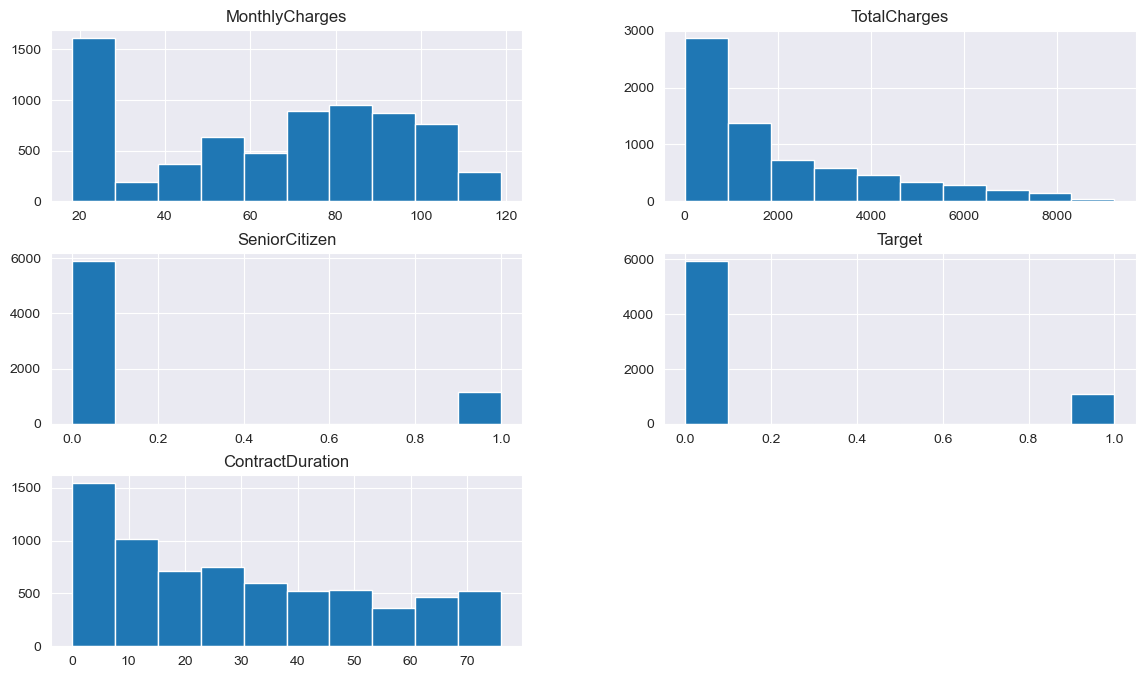

In [63]:
df.hist(figsize=(14,8))

plt.show()

Так же видим дисбаланс классов целевого признака:

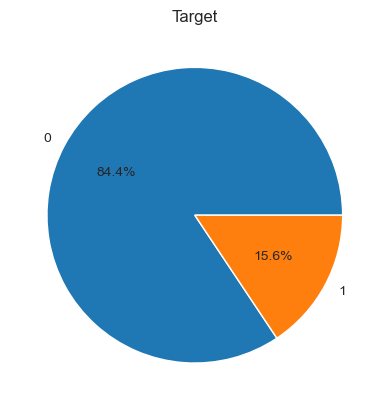

In [64]:
round_graph(df, 'Target')

Проверим признак MonthlyCharges на наличие аномалий:

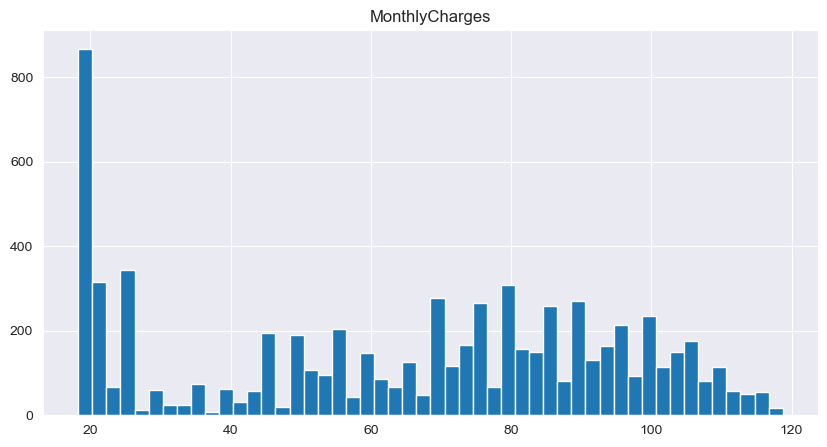

In [65]:
df.MonthlyCharges.hist(bins=50, figsize=(10,5))

plt.title('MonthlyCharges')
plt.show()

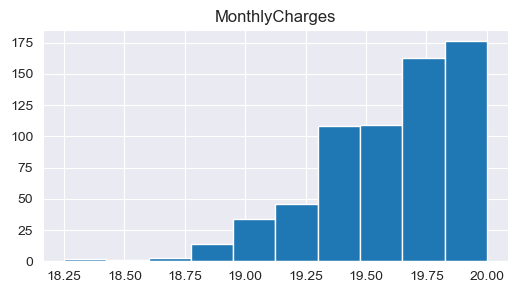

In [66]:
df.query('MonthlyCharges <= 20').MonthlyCharges.hist(figsize=(6,3))

plt.title('MonthlyCharges')
plt.show()

Аномальных значений не обнаружено

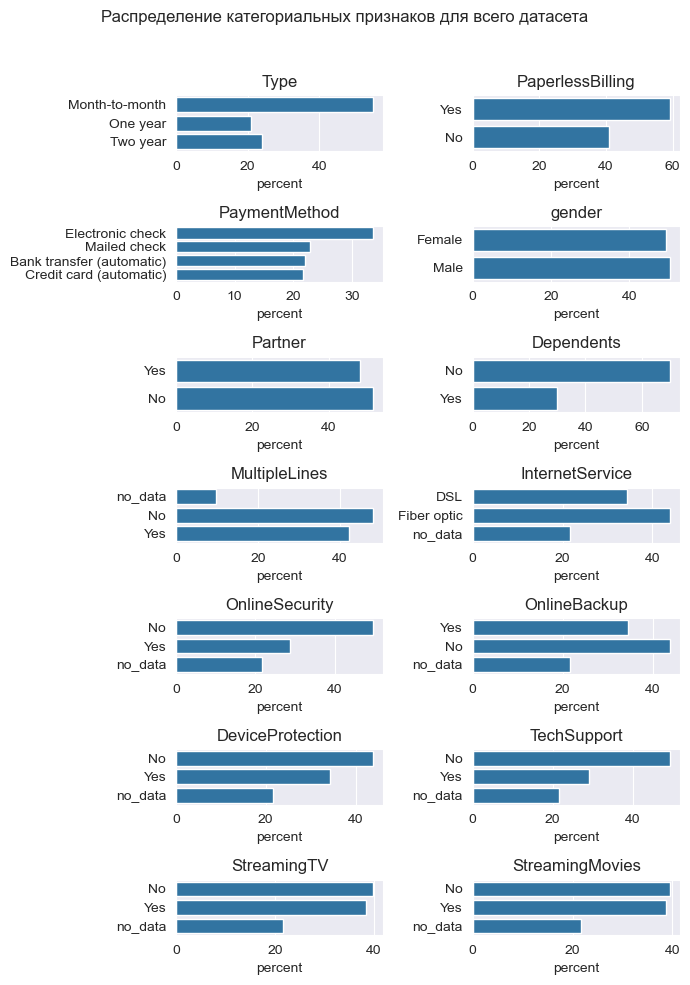

In [67]:
fig, axes = plt.subplots(7, 2, figsize=(7, 10))
i = 0
j = 0

plt.suptitle('Распределение категориальных признаков для всего датасета')

for d in df.select_dtypes('str').columns:
            
    sns.countplot(data=df, y=d, stat='percent', ax=axes[i,j])
    
    axes[i, j].set_ylabel('')
    axes[i, j].set_title(d) 

    j += 1
    if j >= 2:
        j = 0
        i += 1
        
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Никаких аномальных значений так же не выявлено

Рассмотрим по срезу целевого признака:

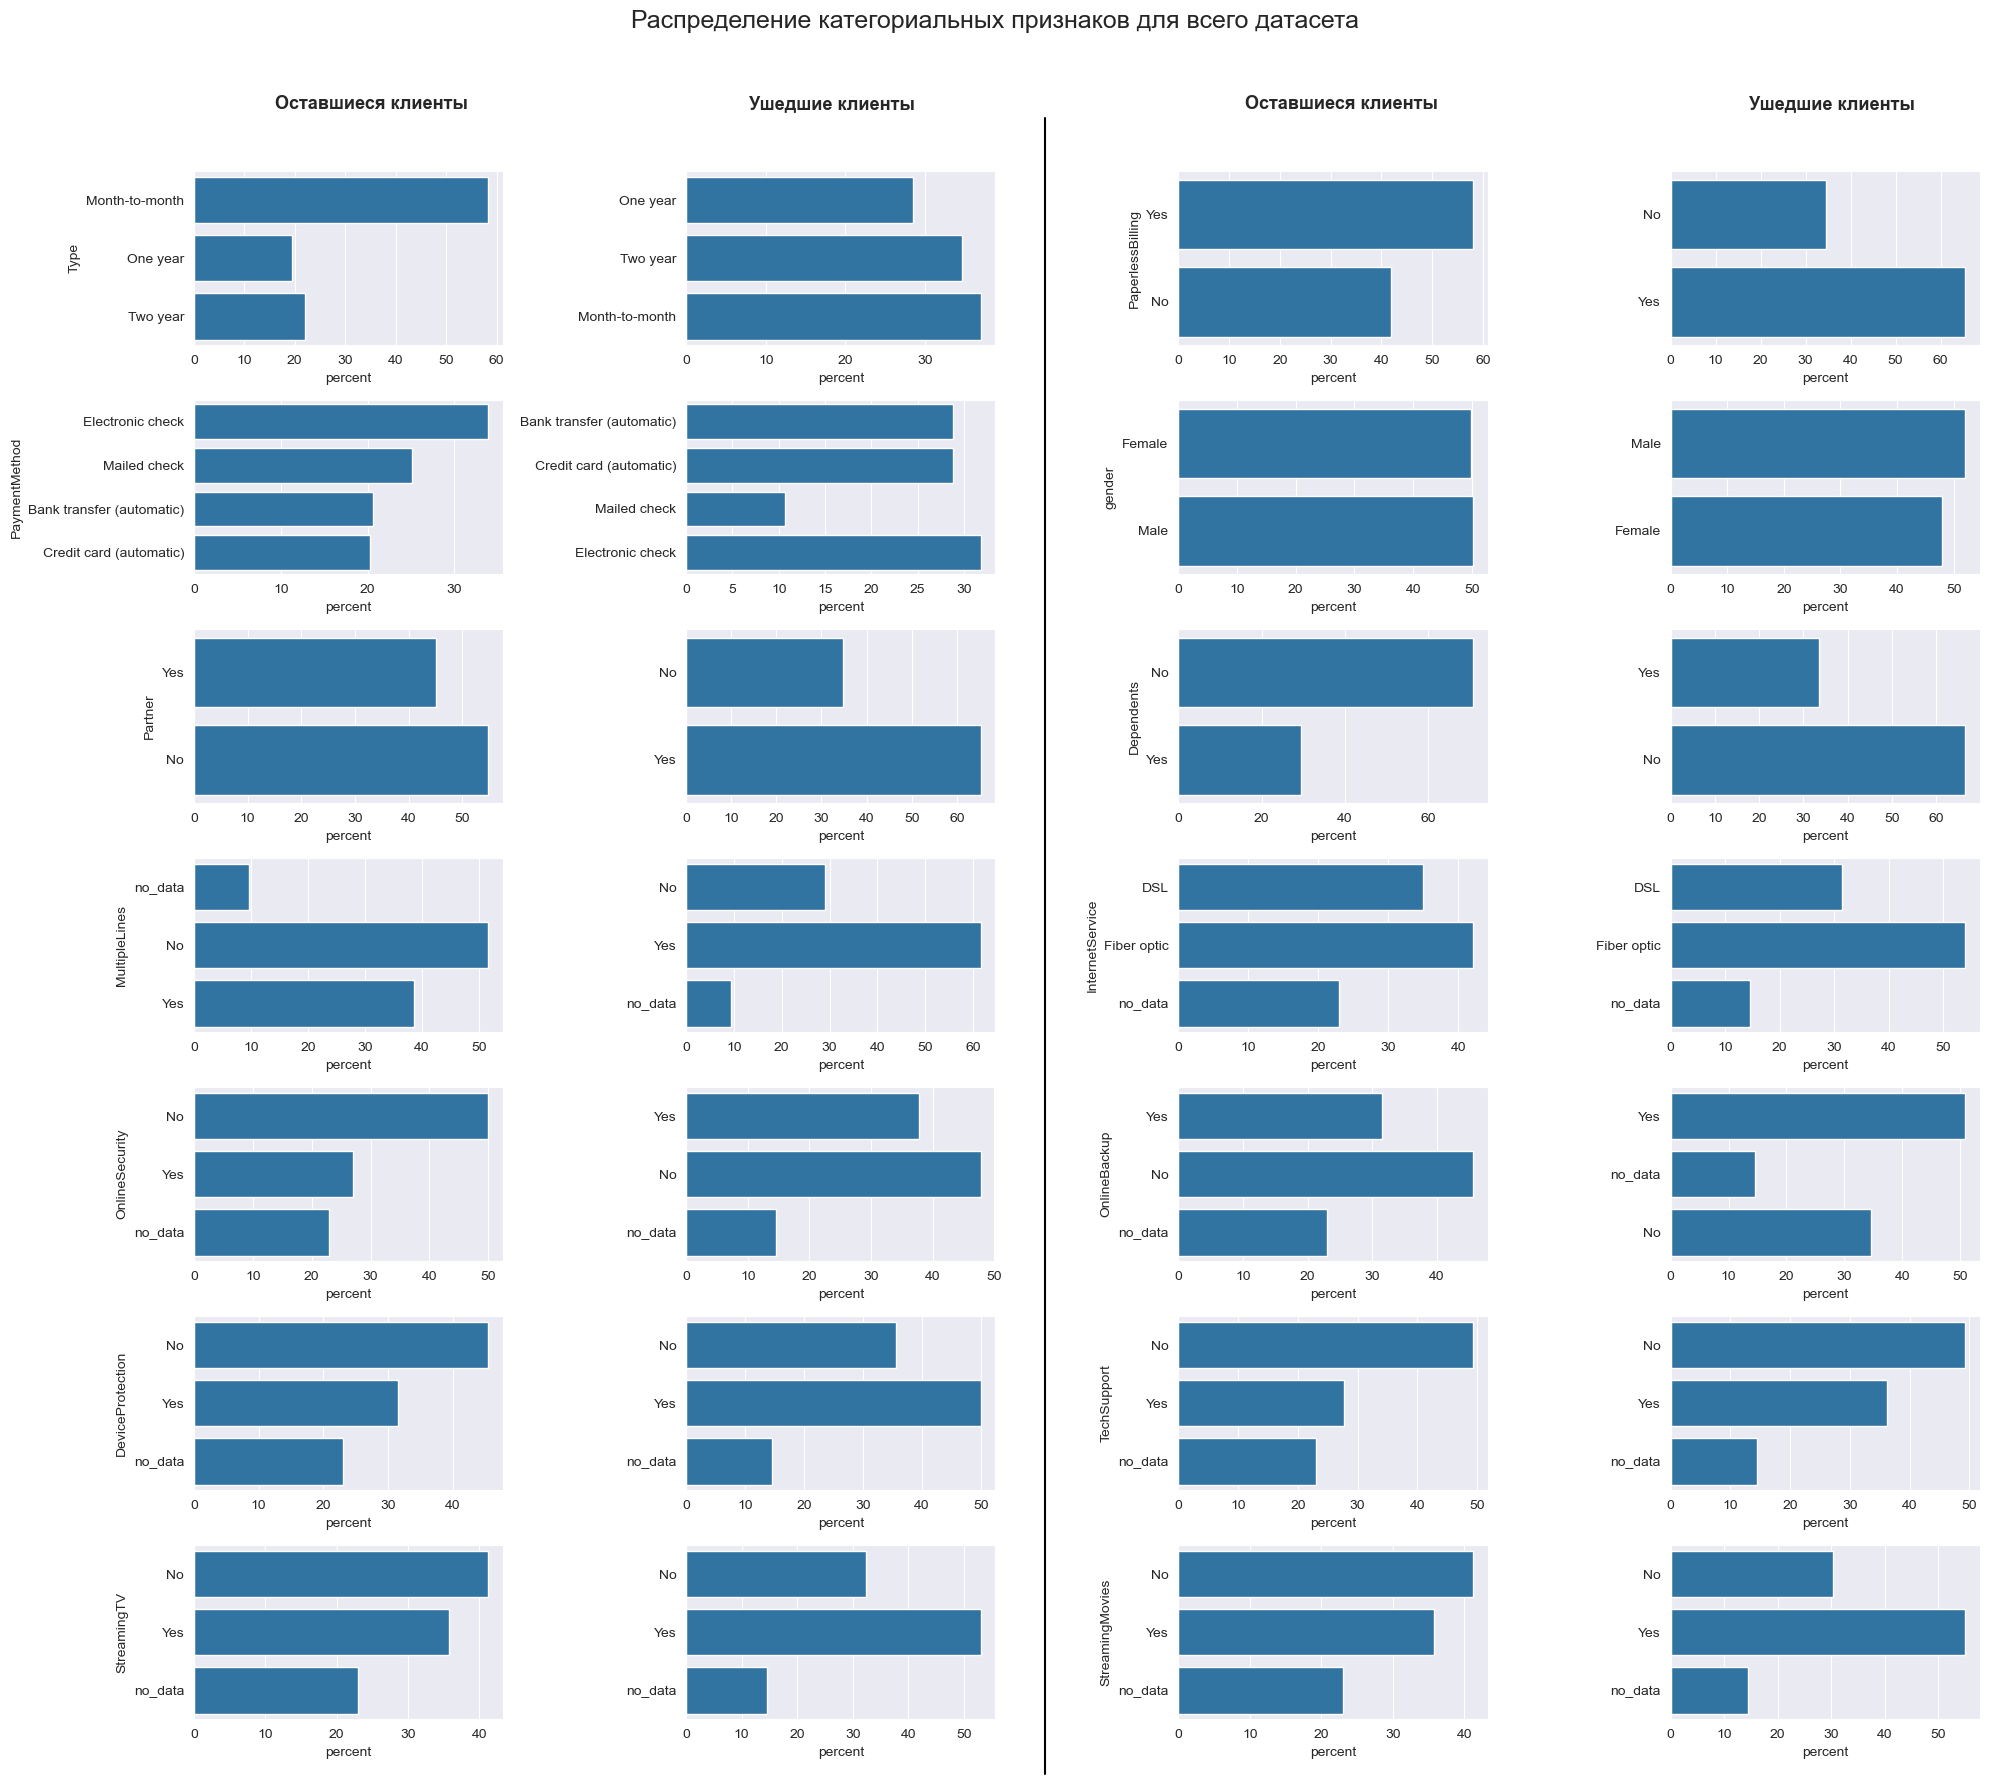

In [68]:
fig, axes = plt.subplots(7, 4, figsize=(20, 18))
i = 0
j = 0

plt.suptitle('Распределение категориальных признаков для всего датасета', fontsize=18)

fig.text(0.14, 0.925, 'Оставшиеся клиенты', fontsize=13, fontweight='bold')
fig.text(0.377, 0.925, 'Ушедшие клиенты', fontsize=13, fontweight='bold')

fig.text(0.625, 0.925, 'Оставшиеся клиенты', fontsize=13, fontweight='bold')
fig.text(0.877, 0.925, 'Ушедшие клиенты', fontsize=13, fontweight='bold')

for d in df.select_dtypes('str').columns:
    for r in islice(cycle([0, 1]), 2):
            
        sns.countplot(data=df.query(f'Target == {r}'), y=d, stat='percent', ax=axes[i,j])
    
        if j == 1 or j == 3:
            axes[i, j].set_ylabel('')
        
        j += 1
            
        if j >= 4:
            j = 0
            i += 1
        
plt.tight_layout(rect=[0, 0, 1, 0.92])

fig.add_artist(
    Line2D(
        [0.525, 0.525], 
        [0, 0.92], 
        transform=fig.transFigure,
        color='black'
    )
)
plt.show()

Количественные признаки в срезе таргета:

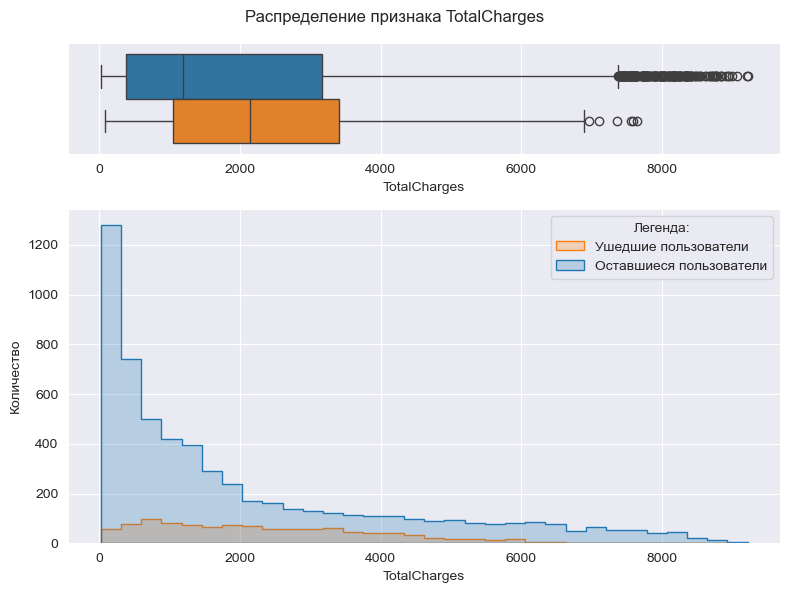

In [69]:
num_grtaph(df, 'TotalCharges')

Общие траты ушедших пользователей распределены более равномерно

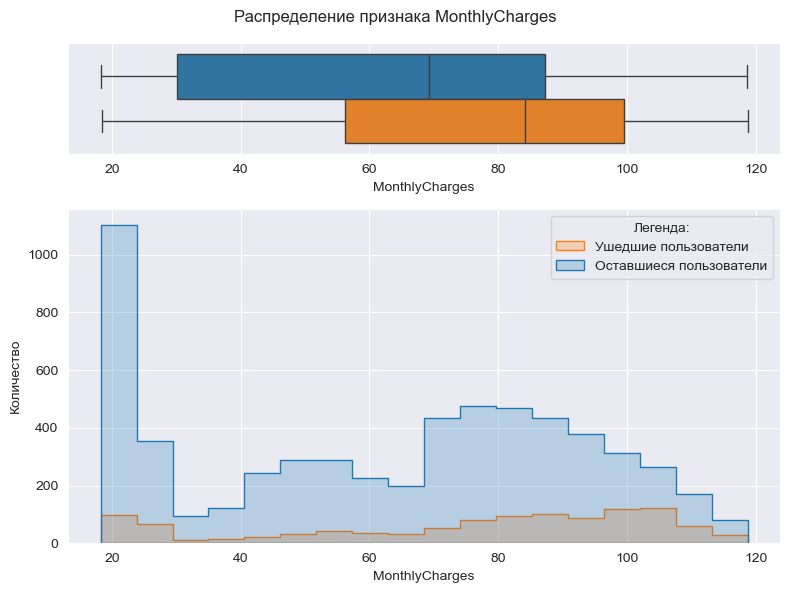

In [70]:
num_grtaph(df, 'MonthlyCharges')

Медиана месячных трат ушедших пользователей выше оставшихся - ушедшие пользователи платили больше

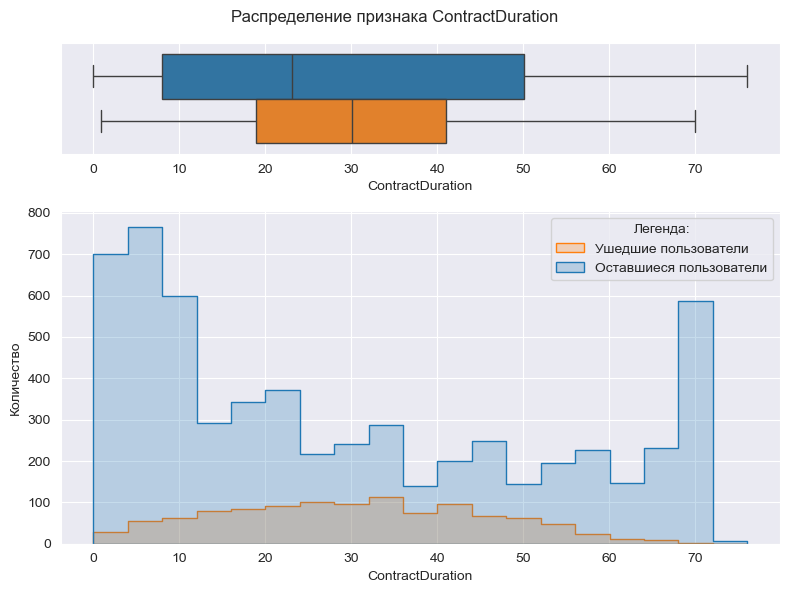

In [71]:
num_grtaph(df, 'ContractDuration')

Распредление для оставшихся пользователей гораздо более широкое

Таким образом, можно определить портрет ушедшего клиента:
- предпочитает помесячную оплату (вероятно, пользователи, уже заплатившие на год вперед, тяжелее расторгают договор);
- пользуются электронными расчетным листом и оплатой;
- вероятнее имеет семью, но без детей;
- подключен к нескольким телефонным линиям;
- платил больше в месяц;
- чаще пользуется цифровыми услугами (в т.ч. антивирусом).

### Анализ корреляции

Проанализируем корреляцию признаков. Оценим категориальные признаки методом PhiK, количественные - Спирмана.

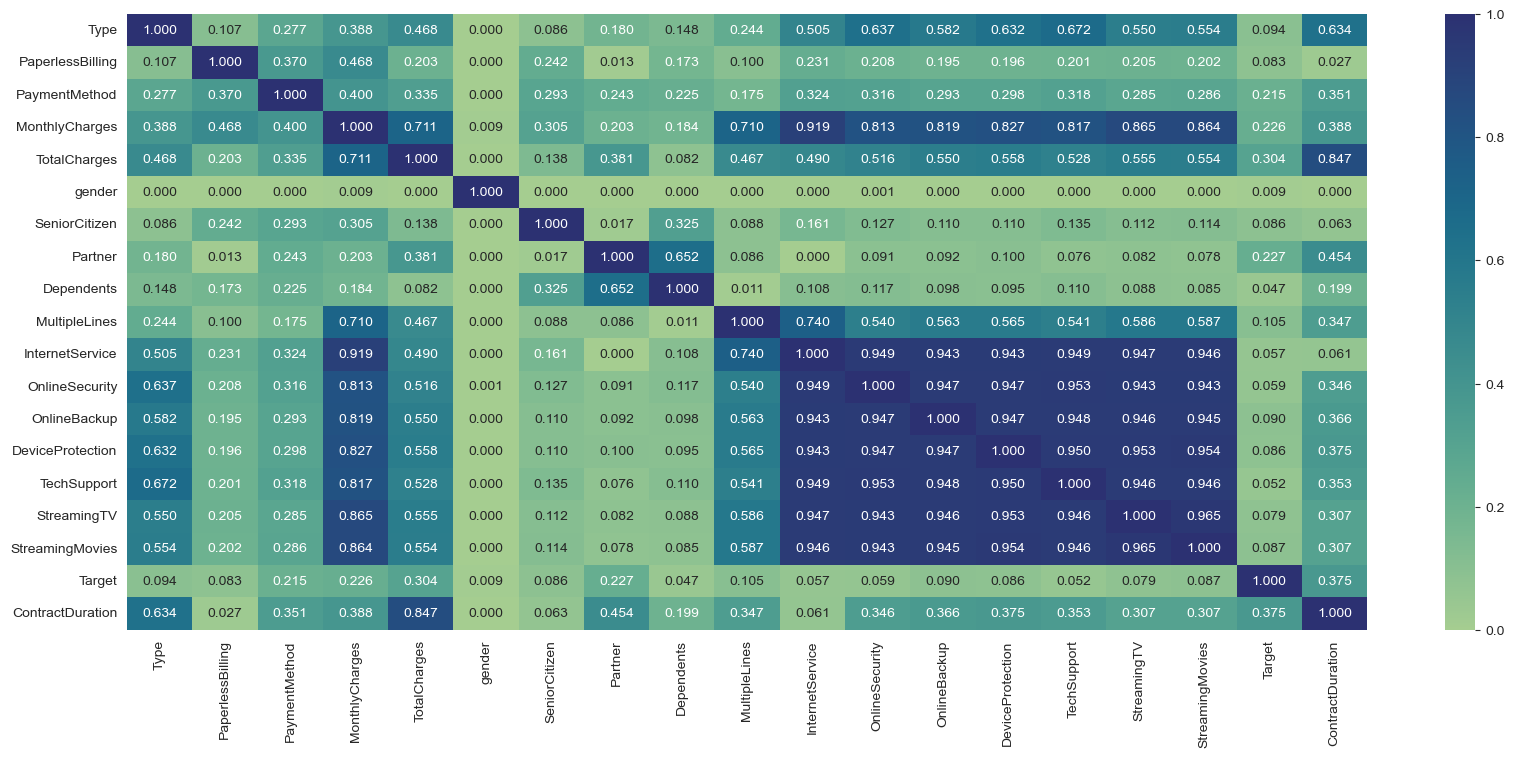

In [72]:
plt.figure(figsize=(20,8))
sns.heatmap(df
			.phik_matrix(verbose=False), annot=True, fmt='.3f', cmap='crest'
		   )

plt.show()

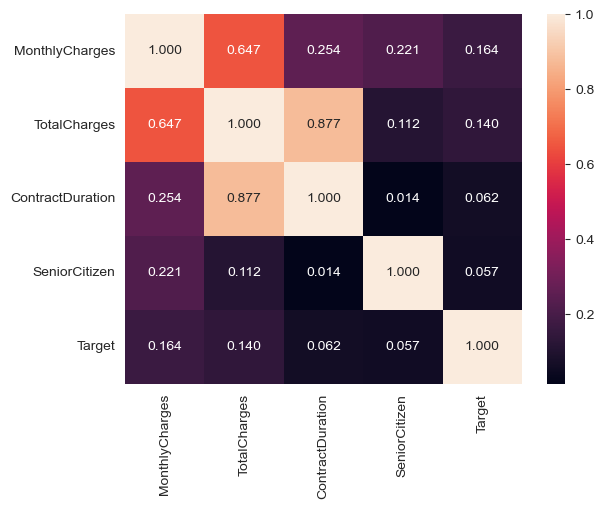

In [73]:
sns.heatmap(df
			[['MonthlyCharges', 'TotalCharges', 'ContractDuration', 'SeniorCitizen', 'Target']]
			.corr(method='spearman'), annot=True, fmt='.3f')

plt.show()

Заметим, что количественные слабо коррелируют с таргетом, помесячная оплата и суммарная оплата ожидаемо между собой связаны. При этом среди категориальных так же нет сильной корреляции, при этом наблюдается мультиколлинеарность между целым рядом входных признаков.

И из анализа корреляции, и из анализа графиков видно, что пол не влияет на отток покупателей. Позже исключим этот и некоторые другие шумные признаки, заменив другими

Сгенерируем дополнительные признаки:

In [74]:
services = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['NumServices'] = (df[services].eq('Yes').sum(axis=1))

In [75]:
support = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport'
]

df['NumSupport'] = (df[support].eq('Yes').sum(axis=1))

In [76]:
df['RiskyCustomers'] = ((df['Type'] == 'Month-to-month') & (df['PaymentMethod'] == 'Electronic check')).astype(int)

In [77]:
df = df.drop(['gender'], axis=1)

In [78]:
df = df.drop(['Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'], axis=1)

Проверим корреляцию еще раз:

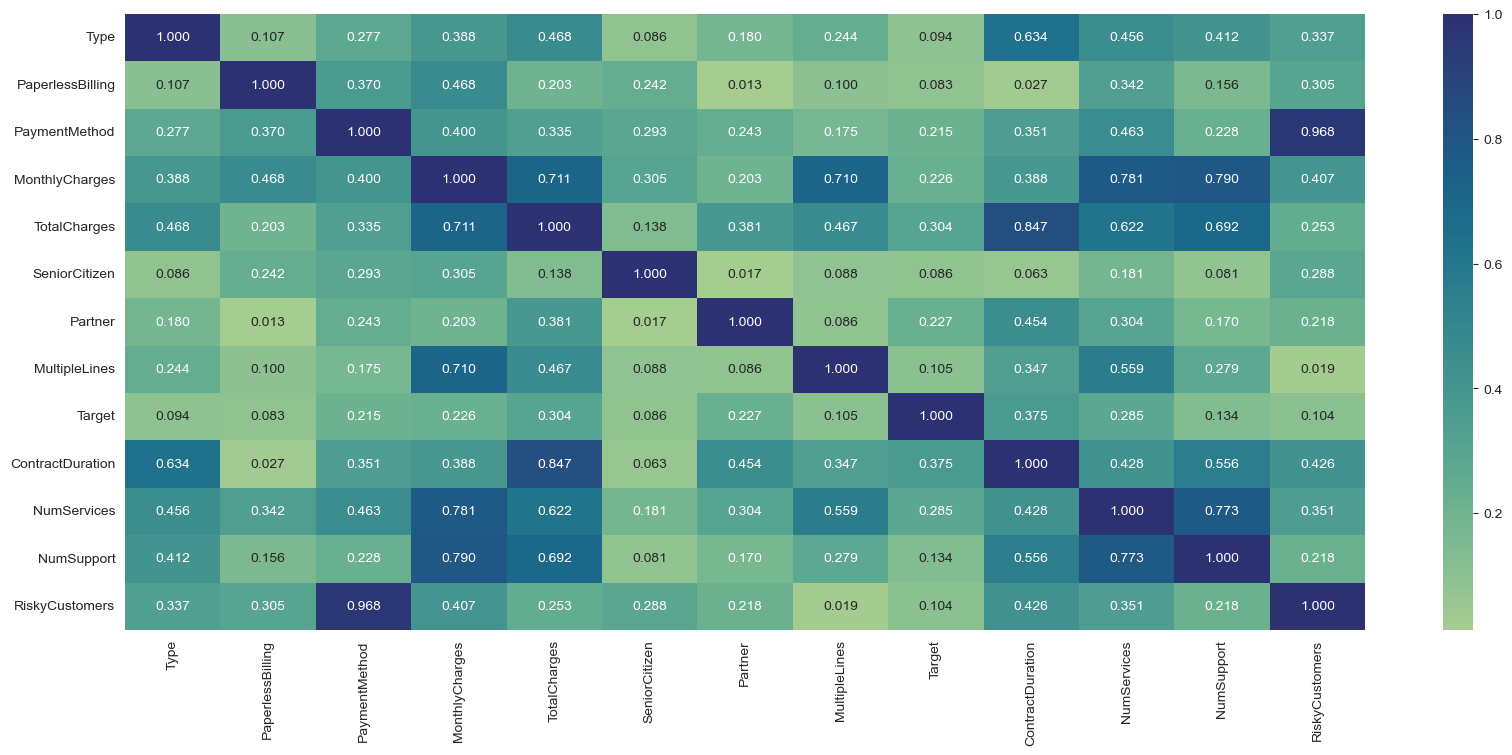

In [79]:
plt.figure(figsize=(20,8))
sns.heatmap(df
			.phik_matrix(verbose=False), annot=True, fmt='.3f', cmap='crest'
		   )

plt.show()

Произведем анализ важности получившихся признаков

In [80]:
Ex = df.drop(['Target'], axis=1)

In [81]:
w = df['Target']

In [82]:
cat_col = list(df.select_dtypes('str').columns)

In [83]:
cat_col.remove('PaymentMethod')

In [84]:
ord = OrdinalEncoder()

In [85]:
ord.fit(Ex[['PaymentMethod']])
ord_col_names = ord.get_feature_names_out()

In [86]:
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

In [87]:
ohe.fit(Ex[cat_col])
ohe_col_names = ohe.get_feature_names_out()

In [88]:
Ex[ohe_col_names] = ohe.transform(Ex[cat_col])
Ex[ord_col_names] = ord.transform(Ex[['PaymentMethod']])
Ex = Ex.drop(cat_col,axis=1)

In [89]:
scorer = mutual_info_classif(Ex, w)

Сохраним 5 наиболее важных

In [90]:
k = 5

In [91]:
top_k_features = SelectKBest(mutual_info_classif, k=k)
top_k_features.fit(Ex, w)
mask = top_k_features.get_support()

In [92]:
X_new = top_k_features.transform(Ex)

In [93]:
top_k_features.get_feature_names_out()

array(['TotalCharges', 'ContractDuration', 'NumServices', 'NumSupport',
       'MultipleLines_Yes'], dtype=object)

In [94]:
mut_cols = list(top_k_features.get_feature_names_out())

In [95]:
mut_cols[4] = 'MultipleLines'

In [96]:
mut_cols.append('Target')

Корреляция новых признаков с таргетом выше первоначальных

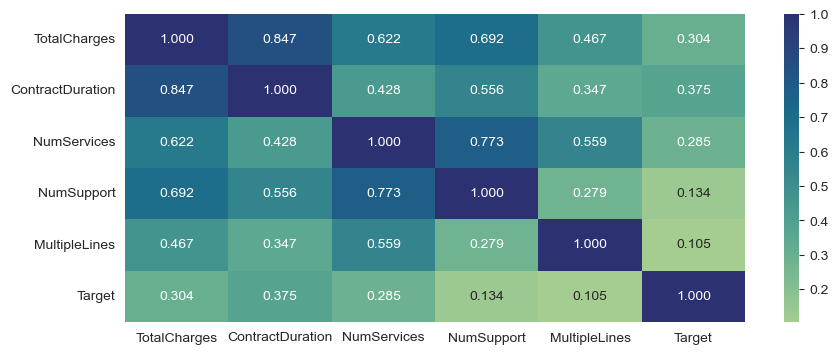

In [97]:
plt.figure(figsize=(10,4))
sns.heatmap(df[mut_cols]
			.phik_matrix(verbose=False), annot=True, fmt='.3f', cmap='crest'
		   )

plt.show()

In [98]:
df = df[mut_cols]

__Вывод:__ мы рассмотрели распределения признаков а так же зависимости признаков между собой и целевым. Отметим, что признаки распределены достаточно равномерно, не наблюдается особых шумов и выбросов, которые могли бы сказываться на предсказаниях модели. Так же заметны различия в графиках признаков для 2 категорий таргета, что говорит об их различимости между собой. Дисбаланс таргета требует дополнительной обработки на этапе разбиения выборок. Признаки в целом имеют невысокую корреляцию с таргетом; самым коррелирующим признаком является созданный нами ContractDuration. Исключены неинформативные слабо коррелирующие с таргетом признаки

## Подготовка данных

Произведем подготовку данных для работы модели.

In [99]:
def data_split(data, target='Target', RANDOM_STATE=RANDOM_STATE, TEST_SIZE=0.25):
	X_train, X_test, y_train, y_test = train_test_split(
		data.drop(target, axis=1),
		data[target],
		test_size=TEST_SIZE, 
		random_state=RANDOM_STATE,
        stratify=data[target]
	)
	return X_train, X_test, y_train, y_test

In [100]:
num_col = list(df.select_dtypes('float').columns)

In [101]:
cat_col = list(df.select_dtypes('str').columns)

Разобьем данные:

In [102]:
X_train, X_test, y_train, y_test = data_split(df)

Закодируем категориальные признаки методом ohe.

In [103]:
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

In [104]:
ohe.fit(X_train[cat_col])
ohe_col_names = ohe.get_feature_names_out()

In [105]:
X_train[ohe_col_names] = ohe.transform(X_train[cat_col])
X_test[ohe_col_names] = ohe.transform(X_test[cat_col])
X_train = X_train.drop(cat_col,axis=1)
X_test = X_test.drop(cat_col,axis=1)

Нормализуем количественные:

In [106]:
scaler = MinMaxScaler()

In [107]:
X_train[num_col] = scaler.fit_transform(X_train[num_col])
X_test[num_col] = scaler.transform(X_test[num_col])

## Создание модели

### Baseline

В качестве проверки адекватности нашей модели будем использовать простую логистическую регрессию как бейзлайн:

In [108]:
lr = LogisticRegression(max_iter=2000)

In [109]:
lr.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [110]:
roc_auc_score(y_train, lr.predict(X_train))

0.5167010989345378

### Кросс-валидация

Для определения лучшей модели проведем кросс-валидацию с помощью инструмента Optuna.

Стратифицируем фолды:

In [111]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Отключим оповещения

In [112]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

Функции моделей для перебора гиперпараметров:

In [113]:
def rf_trial(trial):
	return RandomForestClassifier(
		n_estimators=trial.suggest_int('rf_n_estimators', 300, 800),
        max_depth=trial.suggest_int('rf_max_', 10, 30),
        random_state=RANDOM_STATE,
        n_jobs=-1
	)

In [114]:
def lgb_trial(trial):
	return LGBMClassifier(
		n_estimators=trial.suggest_int('lgb_n_estimators', 200, 800),
		learning_rate=trial.suggest_float('lgb_lr', 1e-3, 0.5, log=True),
		num_leaves=trial.suggest_int('lgb_num_leaves', 2, 160),
        verbosity=-1,
        callbacks=[lgb.early_stopping(stopping_rounds=30)],
		random_state=RANDOM_STATE
	)

In [115]:
def xgboost_trial(trial):
    return XGBClassifier(
        n_estimators=trial.suggest_categorical('xgb_n_estimators', [300, 500, 800, 1200]),
        max_depth=trial.suggest_int('xgb_max_depth', 3, 8),
        learning_rate=trial.suggest_categorical('xgb_learning_rate', [0.01, 0.03, 0.05, 0.1]),
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        tree_method='hist',
        verbosity=0,
        n_jobs=-1
    )

In [116]:
def catboost_trial(trial):
    return CatBoostClassifier(
        iterations=trial.suggest_categorical('cb_iterations', [500, 1000, 1500, 2000]),
        depth=trial.suggest_int('cb_depth', 4, 10),
        learning_rate=trial.suggest_categorical('cb_lr', [0.001, 0.01, 0.03, 0.1]),
        verbose=False,
        random_state=RANDOM_STATE
    )

In [117]:
def mlpc_trial(trial):
	return MLPClassifier(
        hidden_layer_sizes = (
            trial.suggest_int('nn_h1', 32, 64),
            trial.suggest_int('nn_h2', 16, 32),
            trial.suggest_int('nn_h3', 8, 16)
            ),
        learning_rate_init = trial.suggest_float('nn_lr', 1e-5, 1e-3, log=True),
        verbose=False,
        early_stopping=True,
		random_state=RANDOM_STATE
	)

Оценивать будем между 3 бустинг моделями, случайным лесом и нейросетью

In [118]:
models_trial = {
	'RandomForestClassifier': rf_trial,
	'LGBMClassifier': lgb_trial,
	'CatBoostClassifier': catboost_trial,
    'XGBoost': xgboost_trial,
	'MLPClassifier': mlpc_trial
}

Метрика для оценивания ROC-AUC:

In [119]:
def objective(trial):

	model_name = trial.suggest_categorical('model', list(models_trial))

	model = models_trial[model_name](trial)

	score = cross_val_score(
		model,
		X_train,
		y_train,
		cv=skf,
		scoring='roc_auc'
	).mean()

	return score

In [120]:
study = optuna.create_study(direction='maximize')

In [121]:
%%time
study.optimize(objective, n_trials=200, show_progress_bar=True, catch=(Exception,))

  0%|          | 0/200 [00:00<?, ?it/s]

CPU times: total: 3h 59min 5s
Wall time: 20min 16s


Метрика лучшей модели и её гиперпараметры:

In [122]:
study.best_trial.value

0.9053355532089682

In [123]:
study.best_trial.params

{'model': 'CatBoostClassifier',
 'cb_iterations': 500,
 'cb_depth': 5,
 'cb_lr': 0.1}

### Обучение модели и тестирование

Лучшие параметры и модель выявлена. Проведем тестирование:

In [124]:
def summaries_classification(y, y_pred, y_preds_proba=None, mod_name='Название модели'):
	chars = [
		accuracy_score(y, y_pred),
		recall_score(y, y_pred, pos_label=1),
		precision_score(y, y_pred, pos_label=1),
		f1_score(y, y_pred, pos_label=1),
		roc_auc_score(y, y_preds_proba[:,1]),
	]
			
	return pd.DataFrame(
		data=chars,
		index=['Accuracy(Точность)', 'Recall(Полнота)', 'Precision(Прецизионность)', 'F1-score(F1-мера)', 'ROC-AUC'],
		columns=[mod_name])

Инициализируем и обучим данную модель с оперделенными лучшими гиперпараметрами

In [125]:
model_name = study.best_trial.params['model']

In [126]:
if model_name == 'XGBClassifier':
    model = XGBClassifier(
        n_estimators=study.best_trial.params['xgb_n_estimators'],
    	max_depth=study.best_trial.params['xgb_max_depth'],
    	earning_rate=study.best_trial.params['xgb_learning_rate'],
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        tree_method='hist',
        verbosity=0,
        n_jobs=-1
        )
elif model_name == 'CatBoostClassifier':
    model = CatBoostClassifier(
        iterations=study.best_trial.params['cb_iterations'],
        depth=study.best_trial.params['cb_depth'],
        learning_rate=study.best_trial.params['cb_lr'],
        verbose=False,
        random_state=RANDOM_STATE
    )
elif model_name == 'RandomForestClassifier':
    model = RandomForestClassifier(
        n_estimators=study.best_trial.params['rf_n_estimators'],
        max_depth=study.best_trial.params['rf_max_'],
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
elif model_name == 'LGBMClassifier':
    model = LGBMClassifier(
        n_estimators=study.best_trial.params['lgb_n_estimators'],
		learning_rate=study.best_trial.params['lgb_lr'],
		num_leaves=study.best_trial.params['lgb_num_leaves'],
        verbosity=-1,
        callbacks=[lgb.early_stopping(stopping_rounds=30)],
		random_state=RANDOM_STATE
	)
else:
    model = MLPClassifier(
        hidden_layer_sizes=(
            study.best_trial.params['nn_h1'],
            study.best_trial.params['nn_h2'],
            study.best_trial.params['nn_h3']
            ),
        learning_rate_init=study.best_trial.params['nn_lr'],
        verbose=False,
        early_stopping=True,
		random_state=RANDOM_STATE
        )

Выполним предсказание:

In [127]:
model.fit(X_train, y_train)

CatBoostClassifier(depth=5, iterations=500, learning_rate=0.1, random_state=2082026, verbose=False)

In [128]:
preds = model.predict(X_test)
preds_proba = model.predict_proba(X_test)

In [129]:
roc_auc_score(y_test, preds_proba[:,1])

0.9266536155634406

Получена высокая метрика на тестовой выборке. Условие задания выполнено

## Анализ результатов

### Метрики модели

Оценим общее качество работы модели:

In [130]:
summaries_classification(y_test, preds, preds_proba, mod_name=model_name)

,CatBoostClassifier
Accuracy(Точность),0.935832
Recall(Полнота),0.621818
Precision(Прецизионность),0.950000
F1-score(F1-мера),0.751648
ROC-AUC,0.926654


Отметим высокую точность и прецизионность, но низкую полноту. Можно предположить что это вызвано дисбалансом классов, что затрудняет модели отличать положительную метку. Несмотря на удовлетворение условиям задания, в дальнейшей работе рекомендуется поднять значение полноты как наиболее бизнес-полезную метрику в вопросе отслеживания оттока клиентов.

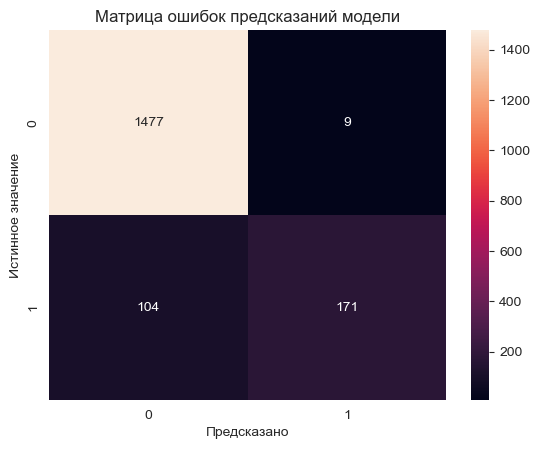

In [131]:
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d')

plt.title('Матрица ошибок предсказаний модели')
plt.ylabel('Истинное значение')
plt.xlabel('Предсказано')
plt.show()

В матрице ошибок можно воочию увидеть работу данных метрик. В то время как метки 0 были угаданы почти все, метки 1 таргета модель различает с трудом.

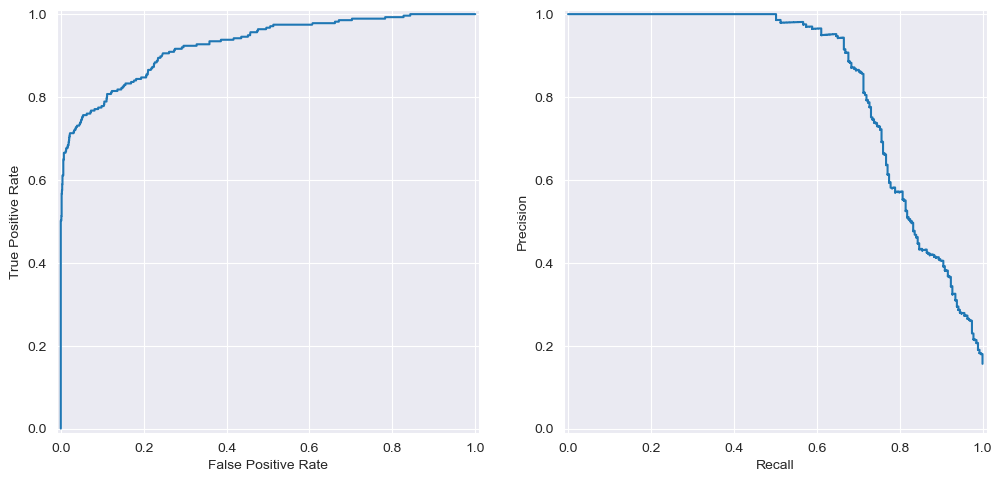

In [132]:
precision, recall, _ = precision_recall_curve(y_test, preds_proba[:,1])
pr_display = PrecisionRecallDisplay(precision=precision, recall=recall)

fpr, tpr, _ = roc_curve(y_test, preds_proba[:,1])
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

roc_display.plot(ax=ax1)
pr_display.plot(ax=ax2)

plt.show()

Рост полноты модели неизбежно вызовет снижение прецизионности - модель станет чаще ошибаться в метках 0 ценой увеличения верного опредления положительных меток.

### Анализ ценности признаков

Рассмотрим вклад признаков в предсказание модели с помощью инструментов библиотеки SHAP.

In [133]:
feature_names = X_test.columns.tolist()

In [134]:
explainer = shap.TreeExplainer(model)

In [135]:
shap_values = explainer(X_test)

Ожидаемо, главными контрибуторами являются время и деньги - эти признаки сильнее всего смещали предсказания в ту или иную сторону.

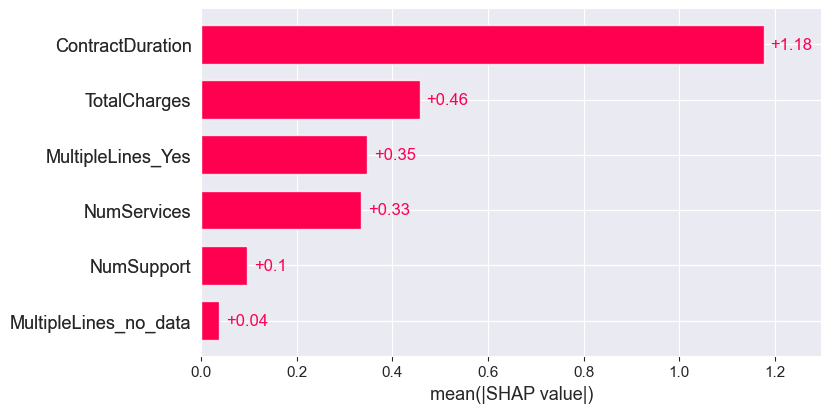

In [136]:
shap.plots.bar(shap_values, max_display=15)

In [137]:
expected_value = explainer.expected_value

Остальные признаки практически не смещают предсказания: именно 4 главных оказывает решающее влияние на исход:

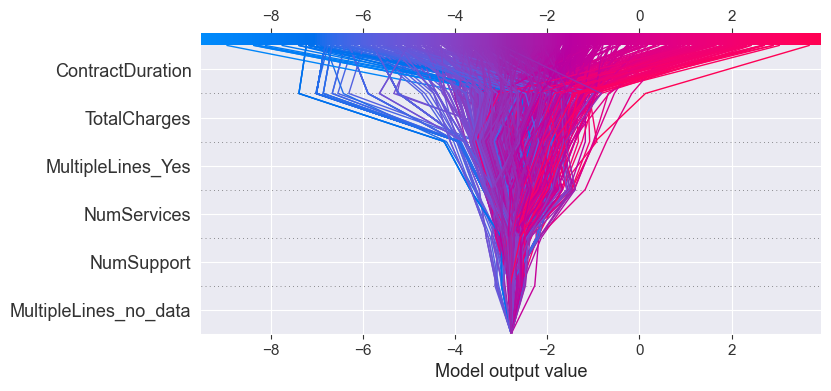

In [138]:
shap.decision_plot(expected_value, explainer.shap_values(shap.sample(X_test, 1000)), feature_names=feature_names)

Соответстенно для самых сильных признаков:
- высокая длительность контракта снижает вероятность ухода клиента;
- при этом высокие суммарные траты не могут ничего однозначно сказать о вероятности ухода, а низкие траты вероятнее всего говорят, что клиент уходить не собирается. Можно предположить, что это влияние новых клиентов, еще не успевших заплатить большие суммы.

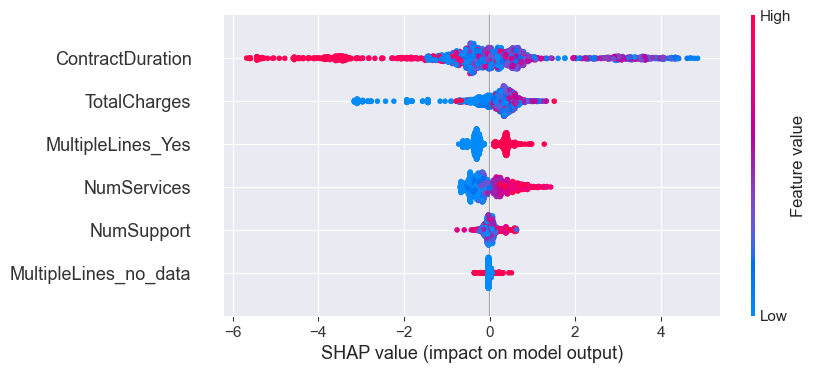

In [139]:
shap.plots.beeswarm(shap_values, max_display=15)

### Анализ признака

Рассмотрим чуть подробнее признак суммарных трат пользователей.

In [140]:
shap_values.data = np.array(shap_values.data)

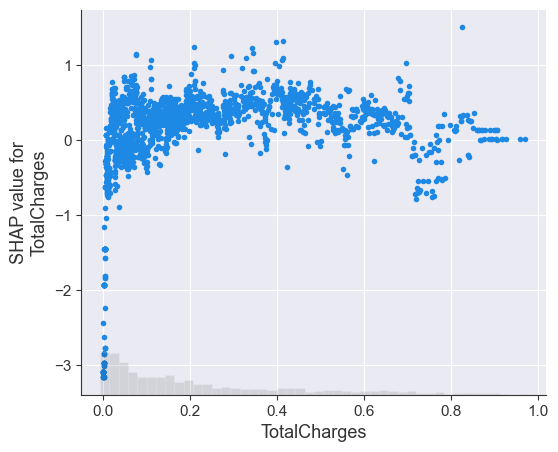

In [141]:
shap.plots.scatter(shap_values[:,0])

Распредление достаточно равномерное. Наблюдаем небольшой кластер значений > 0 и < 0.5 (в кодировке), которые стягивают предсказания к положительному классу. При этом клиенты, не оплачивавшие услуги, скорее склоняют модель к постановке метки "0". В итоге, можем сказать, что данный признак не дает уверенно различать значения таргета для модели.

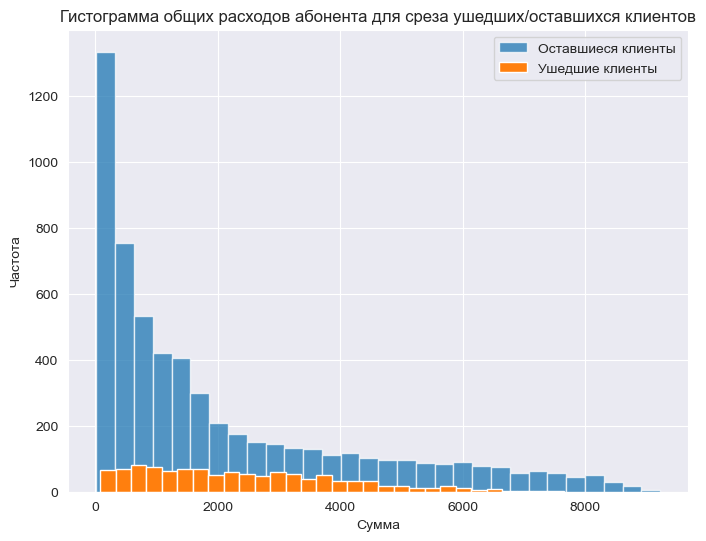

In [142]:
ax = df.query('Target == 0')['TotalCharges'].plot(kind='hist', bins=30, alpha=0.75, figsize=(8,6))
df.query('Target == 1')['TotalCharges'].plot(kind='hist', bins=30, ax=ax)

plt.title('Гистограмма общих расходов абонента для среза ушедших/оставшихся клиентов')
plt.ylabel('Частота')
plt.xlabel('Сумма')
plt.legend(['Оставшиеся клиенты', 'Ушедшие клиенты'])

plt.show()

Гистограмма расходов в срезе по таргету подтверждает это наблюдение: расходы ушедших клиентов распределены более равномерно и стянуты к меньшим значениям, на значениях больше 6000 наблюдений практически нет

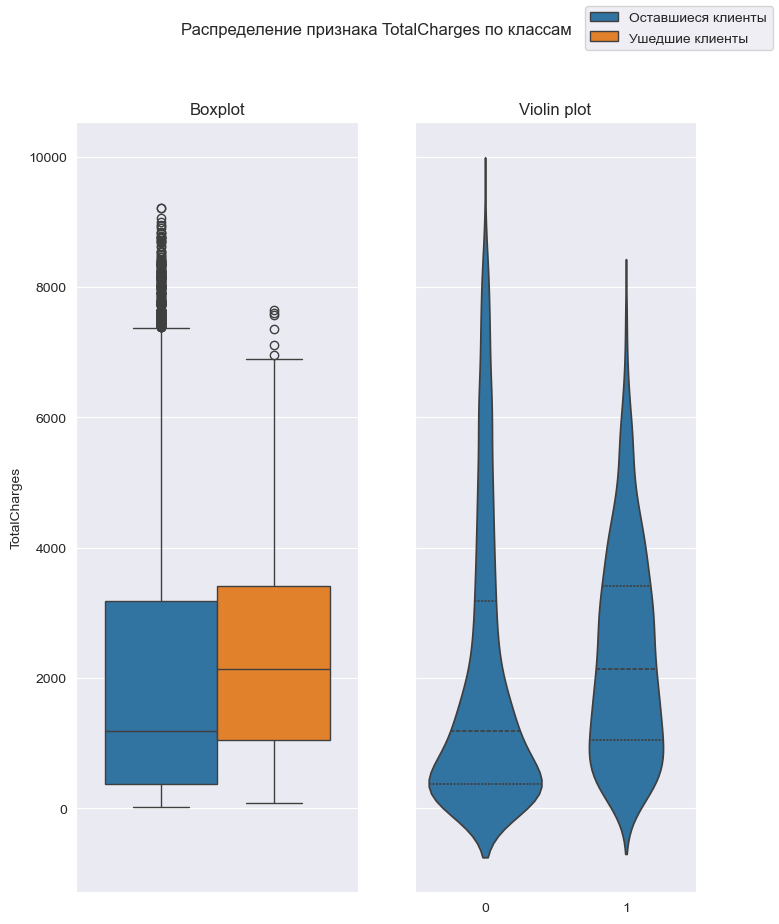

<Figure size 300x800 with 0 Axes>

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(8, 10), sharey=True)

plt.figure(figsize=(3, 8))

sns.boxplot(data=df, y='TotalCharges', orient='v', hue='Target', ax=axes[0], legend=0)
sns.violinplot(data=df, x='Target', y='TotalCharges', ax=axes[1], inner='quart')

axes[1].set_xlabel('')

axes[0].set_title('Boxplot')
axes[1].set_title('Violin plot')

fig.suptitle('Распределение признака TotalCharges по классам')
fig.legend(['Оставшиеся клиенты','Ушедшие клиенты'])
plt.tight_layout()

plt.show()

In [144]:
pd.DataFrame(
    data={'Оставшиеся клиенты': df.query('Target == 0')['TotalCharges'].describe(),
          'Ушедшие клиенты': df.query('Target == 1')['TotalCharges'].describe()
         }
)

,Оставшиеся клиенты,Ушедшие клиенты
count,5942.000000,1101.000000
mean,2067.943095,2371.377275
std,2193.827140,1581.862275
min,19.050000,77.840000
25%,374.352500,1048.050000
50%,1192.800000,2139.030000
75%,3173.837500,3404.910000
max,9221.380000,7649.760000


Такой же вывод можно сделать из анализа "ящика с усами" и "скрипичной диаграммы" - среди ушедший пользователей наблюдается меньше дисперсия, медиана заметно смещена дальше от 0 в сравнении с оставшимися пользователями (на эти графики оказывает большое влияние пользователи, заплатившие суммарно небольшую сумму)

## Выводы

В данной работе была решена задача бинарной классификации. Целью являлось предсказание значения целевого признака на основе набора входных данных о клиентах сервиса телекоммуникационных услуг.<br>
Для оценки качества моделей согласно ТЗ заказчика использовалась метрика ROC-AUC, позволяющая оценить способность модели разделять объекты на классы независимо от порога классификации.

__Были выполнены следующие этапы подготовки данных:__
- подключение к БД, загрузка датафреймов, получение общей информации и анализ данных и распределений;
- предобработка данных: обработка пропусков, дубликатов, поиск аномалий;
- объединение данных по уникальному ключу - ID пользователя, получение таргета из входных признаков;
- корреляционный анализ, на основании которого были исключены часть признаков и созданы новые;
- кодирование и нормализация данных.

В ходе анализа распределения входных признаков был составлен портрет ушедшего пользователя.

После завершения подготовки была проведена кросс-валидация с помощью инструментов библиотеки Optuna. Среди конкурирующих моделей были следующие:<br>
- RandomForestClassifier,
- LGBMClassifier,
- CatBoostClassifier,
- XGBoost,
- MLPClassifier.

Среди комбинаций гиперпараметров были следующие:
- количество деревьев;
- глубина деревьев;
- параметры регуляризации;
- архитектура нейронной сети и т.д.

В результате лучшей моделью была определена _CatBoostClassifier_. Её гиперпараметры: iterations = 1000; depth = 4; learning rate = 0.1. Метрики модели на тесте:

In [145]:
summaries_classification(y_test, preds, preds_proba, mod_name=model_name)

,CatBoostClassifier
Accuracy(Точность),0.935832
Recall(Полнота),0.621818
Precision(Прецизионность),0.950000
F1-score(F1-мера),0.751648
ROC-AUC,0.926654


По результатам исследования был проведен анализ результатов модели и вклада признаков в результат.

__Таким образом__, мы выполнили задачу разработки модели бинарной классификации с требуемым значением метрики.

В качестве перспектив направлений улучшения модели можно указать ориентирование на метрику recall как более ценной для бизнеса. На данном этапе модель упускает достаточно много клиентов, разрывающих контракт. Необходимо вести улучшение модели с целью повышения этой метрики путем, например, увеличения глубины обучения, генерации новых признаков.

На улучшение качества модели окажут больше влияние входные данные. Таким образом, рекомендуется для анализа предосталять большие объемы данных